# GPT Classifier — Area (Zero-Shot)

Classificatore area basato su **GPT-4o-mini** via OpenAI API.
Obiettivo: valutare le prestazioni zero-shot di GPT come baseline,
poi confrontarle con il LinearSVC già addestrato (Macro F1 = 0.66).

**Pipeline:**
1. Stima costi prima di lanciare qualsiasi chiamata
2. Preprocessor testo (stesso usato per gli embedding)
3. Definizione classi + system prompt
4. Modello Pydantic per structured output
5. Funzione di classificazione singolo ticket
6. Valutatore batch su campione del test set
7. Confronto GPT vs LinearSVC

## STEP 0 — Import e configurazione

In [11]:
import os
import re
import time
import json
from pathlib import Path

import pandas as pd
import numpy as np
from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel
from typing import Literal
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Carica variabili d'ambiente dal .env nella root del progetto
load_dotenv(Path('..') / '.env')

# Inizializza client OpenAI — usa OPENAI_API_KEY dal .env
client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))

# Modello da usare — gpt-4o-mini: ottimo rapporto qualità/costo per classificazione
MODELLO = 'gpt-4o-mini'

# Percorso dataset
DATA_PATH = Path('..') / 'data' / 'dataset_clean.csv'

# Split temporale — stesso usato in AreaClassifier per avere lo stesso test set
SOGLIA_SPLIT = '2025-11-01'

print(f'OpenAI client inizializzato')
print(f'Modello: {MODELLO}')
print(f'API key presente: {"✅" if os.getenv("OPENAI_API_KEY") else "❌ NON TROVATA"}')

OpenAI client inizializzato
Modello: gpt-4o-mini
API key presente: ✅


## STEP 1 — Stima costi

**Fare sempre questo calcolo prima di lanciare una valutazione batch.**

`gpt-4o-mini` pricing (Marzo 2026):
- Input:  $0.15 / 1M token
- Output: $0.60 / 1M token

In [12]:
def stima_costo(n_ticket: int, token_input_medi: int = 450, token_output_medi: int = 50) -> None:
    """
    Stima il costo di una valutazione batch su N ticket.

    token_input_medi: ~400 token di system prompt + ~50 token del ticket
    token_output_medi: risposta JSON breve (area + confidenza + reasoning)
    """
    tot_input  = n_ticket * token_input_medi
    tot_output = n_ticket * token_output_medi

    # Prezzi gpt-4o-mini (Marzo 2026)
    costo_input  = (tot_input  / 1_000_000) * 0.15
    costo_output = (tot_output / 1_000_000) * 0.60
    costo_totale = costo_input + costo_output

    print(f'{"─"*40}')
    print(f'  Ticket:        {n_ticket:>8,}')
    print(f'  Token input:   {tot_input:>8,}   → ${costo_input:.4f}')
    print(f'  Token output:  {tot_output:>8,}   → ${costo_output:.4f}')
    print(f'  Costo totale:          → ${costo_totale:.4f}')
    print(f'{"─"*40}')


# Scenari tipici
print('=== STIMA COSTI GPT-4o-mini ===\n')
print('▸ Test rapido (200 ticket):')
stima_costo(200)
print()
print('▸ Valutazione media (500 ticket):')
stima_costo(500)
print()
print('▸ Tutto il test set (10.321 ticket):')
stima_costo(10_321)

=== STIMA COSTI GPT-4o-mini ===

▸ Test rapido (200 ticket):
────────────────────────────────────────
  Ticket:             200
  Token input:     90,000   → $0.0135
  Token output:    10,000   → $0.0060
  Costo totale:          → $0.0195
────────────────────────────────────────

▸ Valutazione media (500 ticket):
────────────────────────────────────────
  Ticket:             500
  Token input:    225,000   → $0.0338
  Token output:    25,000   → $0.0150
  Costo totale:          → $0.0488
────────────────────────────────────────

▸ Tutto il test set (10.321 ticket):
────────────────────────────────────────
  Ticket:          10,321
  Token input:   4,644,450   → $0.6967
  Token output:   516,050   → $0.3096
  Costo totale:          → $1.0063
────────────────────────────────────────


## STEP 2 — Preprocessor testo

Stessa logica del preprocessing principale: rimuove HTML, disclaimer, firma ZHC.
Il testo risultante è quello che finisce nel prompt inviato a GPT.

In [22]:
def prepara_testo(testo_input: str, max_parole: int = 300) -> str:
    """
    Pulisce e tronca il testo da mandare a GPT nel prompt utente.

    Usa testo_input già preprocessato dal Preprocessing.ipynb,
    quindi qui serve solo normalizzare spazi e tagliare per contenere i costi.

    max_parole=150: sufficiente per la classificazione area,
    evita di mandare descrizioni lunghissime che fanno esplodere i costi.
    """
    if not isinstance(testo_input, str) or not testo_input.strip():
        return '[descrizione assente]'

    # Rimuovi eventuali tag HTML residui
    testo = re.sub(r'<[^>]+>', ' ', testo_input)

    # Normalizza spazi multipli e a capo
    testo = re.sub(r'\s+', ' ', testo).strip()

    # Tronca a max_parole per contenere i costi
    parole = testo.split()
    if len(parole) > max_parole:
        testo = ' '.join(parole[:max_parole]) + ' [...]'

    return testo


# Test visivo su una stringa con HTML
testo_esempio = '<p>Buongiorno, <b>ho un problema</b> con la fattura n.123.<br/>Potete aiutarmi?</p>'
print('Input:  ', testo_esempio)
print('Output: ', prepara_testo(testo_esempio))

Input:   <p>Buongiorno, <b>ho un problema</b> con la fattura n.123.<br/>Potete aiutarmi?</p>
Output:  Buongiorno, ho un problema con la fattura n.123. Potete aiutarmi?


## STEP 3 — Classi, Pydantic model e System Prompt

Le 9 classi valide dopo il preprocessing (Hardware, business_intelligence e
protocollo_delibere sono stati droppati/accorpati).

Il `Literal` nel modello Pydantic forza GPT a scegliere **solo** tra le opzioni valide,
eliminando allucinazioni. Questo è il vantaggio chiave di `beta.chat.completions.parse()`.

In [23]:
# ── Dizionario classi con descrizioni restrittive ──────────────────────────
AREE_ZHC = {
    'area_personale':                  'Gestione dipendenti, cedolini, presenze, ferie, HR, buste paga. INCLUDE: "Bilancio di previsione" per costi personale.',
    'ciclo_passivo':                   'Costi e contabilità fornitori. Keyword: fatture ricevute, cespiti, ammortamenti, F24, ritenuta d’acconto, ordini acquisto.',
    'ciclo_attivo':                    'Ricavi e gestione ospiti. Keyword: rette ospiti, fatture emesse, PagoPA, SDD, contratti ospiti, anagrafica parenti.',
    'area_sanitaria':                  'Funzioni cliniche e assistenziali. Keyword: diari infermieristici, PAI, terapie, parametri vitali, cartella clinica, farmaci.',
    'rendicontazione_flussi':          'Invio dati obbligatori a Enti/Regioni. Keyword: flussi SOSIA, FAR, NSIS, debito informativo, SMAF.',
    'protocollo_documentale_delibere': 'Gestione atti formali. Keyword: protocollo, determine, delibere, conservazione sostitutiva, albo online.',
    'area_sistemistica':               'SOLO problemi infrastrutturali (cause). Keyword: server, database SQL, VPN, certificati SSL, installazione client, reset password. NON usare per errori d’uso del software.',
    'sistema381':                      'Software specifico per cooperative sociali. Keyword: rapportini, SIAF, calendario presenze cooperative.',
    'area_territoriale':               'Servizi domiciliari e UnoDomo. Keyword: ADI, SAD, assistenza domiciliare, prestazioni territoriali.',
}

# ── Modello Pydantic — structured output ─────────────────────────────────────
# Literal con le 9 classi esatte: GPT non può restituire valori fuori da questa lista.
AreaType = Literal[
    'area_personale',
    'ciclo_passivo',
    'ciclo_attivo',
    'area_sanitaria',
    'rendicontazione_flussi',
    'protocollo_documentale_delibere',
    'area_sistemistica',
    'sistema381',
    'area_territoriale',
]

class ClassificazioneArea(BaseModel):
    area:       AreaType  # classe predetta — vincolata al Literal
    confidenza: float     # stima soggettiva del modello (0.0 - 1.0)
    reasoning:  str       # max 1 frase — utile per debug e analisi errori


# ── System prompt ─────────────────────────────────────────────────────────────
# Costruito dinamicamente dal dizionario AREE_ZHC per mantenerlo sempre aggiornato.
SYSTEM_PROMPT = (
    "Sei un esperto operatore di helpdesk Zucchetti Healthcare. Classifica l'AREA del ticket analizzando la natura TECNICA del problema.\n\n"
    "REGOLE CRITICHE DI DISAMBIGUAZIONE:\n"
    "1. Se il ticket menziona 'Bilancio di Previsione' -> area_personale (anche se vedi 'bilancio'). [1, 2]\n"
    "2. Se riguarda 'Fornitori' o 'F24' -> ciclo_passivo. [3, 4]\n"
    "3. Se riguarda 'Ospiti', 'Rette' o 'Fatture Emesse' -> ciclo_attivo. [5, 6]\n"
    "4. 'Area Sistemistica' va usata SOLO per blocchi infrastrutturali (server down, VPN, SQL). Se l'utente segnala lentezza in un modulo (es. CSS), usa l'area del modulo (area_sanitaria). [7-9]\n"
    "5. Ignora il linguaggio allarmistico ('URGENTE') per la scelta dell'area.\n\n"
    "AREE DISPONIBILI:\n"
    + '\n'.join(f'- {k}: {v}' for k, v in AREE_ZHC.items())
)

print(f'Classi definite: {len(AREE_ZHC)}')
print(f'System prompt: {len(SYSTEM_PROMPT)} caratteri')
print()
print('Preview system prompt:')
print(SYSTEM_PROMPT[:500] + '...')

Classi definite: 9
System prompt: 1940 caratteri

Preview system prompt:
Sei un esperto operatore di helpdesk Zucchetti Healthcare. Classifica l'AREA del ticket analizzando la natura TECNICA del problema.

REGOLE CRITICHE DI DISAMBIGUAZIONE:
1. Se il ticket menziona 'Bilancio di Previsione' -> area_personale (anche se vedi 'bilancio'). [1, 2]
2. Se riguarda 'Fornitori' o 'F24' -> ciclo_passivo. [3, 4]
3. Se riguarda 'Ospiti', 'Rette' o 'Fatture Emesse' -> ciclo_attivo. [5, 6]
4. 'Area Sistemistica' va usata SOLO per blocchi infrastrutturali (server down, VPN, SQL). S...


## STEP 4 — Funzione di classificazione singolo ticket

## STEP 3b — Esempi Few-Shot per classe

Ogni coppia `user/assistant` simula una classificazione già risolta.
GPT le usa come riferimento prima di classificare il ticket reale.

Le risposte assistant devono essere JSON validi che rispettano il modello Pydantic:
`area`, `confidenza`, `reasoning`.

⚠️ Mancano ancora gli esempi per: `rendicontazione_flussi`, `protocollo_documentale_delibere`, `sistema381`, `area_territoriale` — aggiungili seguendo lo stesso formato.

In [24]:
import json

def _fs(ticket: str, area: str, reasoning: str, confidenza: float = 1.0):
    """Helper: costruisce una coppia user/assistant per il few-shot."""
    return [
        {'role': 'user',      'content': f'TICKET:\n{ticket}'},
        {'role': 'assistant', 'content': json.dumps(
            {'area': area, 'confidenza': confidenza, 'reasoning': reasoning},
            ensure_ascii=False
        )},
    ]

# ── Few-shot messages ─────────────────────────────────────────────────────────
# Ogni _fs() produce 2 messaggi (user + assistant).
# L'ordine non è critico, ma metti prima le classi più confuse.

FEW_SHOT_MESSAGES = [

    # ── area_personale ────────────────────────────────────────────────────────
    *_fs(
        ticket    = 'Buongiorno, ho un errore nel calcolo dei netti della 13.ma per l\'ente 5764. Alcuni importi escono raddoppiati.',
        area      = 'area_personale',
        reasoning = 'Il ticket riguarda il calcolo della tredicesima e i netti a pagare dei dipendenti, funzioni core del modulo paghe.',
    ),
    *_fs(
        ticket    = 'Non riesco ad accedere al Bilancio di Previsione per inserire i costi del personale 2026.',
        area      = 'area_personale',
        reasoning = 'Sebbene usi la parola bilancio, si riferisce al modulo specifico di previsione costi del personale incluso nell\'area HR.',
    ),

    # ── ciclo_attivo ──────────────────────────────────────────────────────────
    *_fs(
        ticket    = 'Urgente, non riesco a caricare il contratto per un nuovo ospite in CUW perché mi dice codice fiscale già presente.',
        area      = 'ciclo_attivo',
        reasoning = 'Si tratta di gestione anagrafica e contrattuale di un ospite finalizzata alla fatturazione della retta.',
    ),
    *_fs(
        ticket    = 'Le fatture elettroniche inviate ai parenti risultano scartate dallo SDI per IBAN errato.',
        area      = 'ciclo_attivo',
        reasoning = 'Riguarda fatturazione attiva emessa verso clienti/parenti e integrazione con il sistema di interscambio.',
    ),

    # ── ciclo_passivo ─────────────────────────────────────────────────────────
    *_fs(
        ticket    = 'Buongiorno, avrei bisogno di inserire in anagrafica un nuovo fornitore a cui dobbiamo pagare una fattura.',
        area      = 'ciclo_passivo',
        reasoning = 'Riguarda la gestione anagrafica dei fornitori e il ciclo degli acquisti/pagamenti.',
    ),
    *_fs(
        ticket    = 'In fase di stampa del bilancio di verifica segnala errore su una fattura di acquisto registrata a novembre.',
        area      = 'ciclo_passivo',
        reasoning = 'Si riferisce alla contabilità generale e alla quadratura del bilancio di verifica.',
    ),

    # ── area_sanitaria ────────────────────────────────────────────────────────
    *_fs(
        ticket    = 'Il medico non riesce a salvare la prescrizione della terapia per l\'ospite Rossi. Dice che non ha i permessi.',
        area      = 'area_sanitaria',
        reasoning = 'Il problema riguarda la funzione clinica di prescrizione farmaci all\'interno della cartella socio-sanitaria.',
    ),
    *_fs(
        ticket    = 'Nella stampa del PAI non vengono visualizzate le note inserite dalla logopedista nella scheda disfagia.',
        area      = 'area_sanitaria',
        reasoning = 'Riguarda la generazione di report clinici (PAI) e il recupero dati da schede di valutazione sanitaria.',
    ),

    # ── area_sistemistica ─────────────────────────────────────────────────────
    # Descrizioni molto specifiche per evitare che venga usata come catch-all.
    # area_sistemistica = SOLO problemi di infrastruttura, server, rete, installazioni.
    # NON va usata per problemi applicativi anche se "tecnici".
    *_fs(
        ticket    = 'Buongiorno, abbiamo cambiato PC in amministrazione e dobbiamo reinstallare il client AdHoc.',
        area      = 'area_sistemistica',
        reasoning = 'Attività di installazione software e configurazione postazione locale, di natura puramente tecnica/infrastrutturale.',
    ),
    *_fs(
        ticket    = 'Urgente! È saltata la luce e ora il server non risponde, non riusciamo a fare il login in nessun programma.',
        area      = 'area_sistemistica',
        reasoning = 'Blocco totale dovuto a cause infrastrutturali (server down/SQL arrestati) che impatta trasversalmente tutti i moduli.',
    ),

    # TODO: aggiungere 2 esempi per ciascuna delle classi mancanti:
    # rendicontazione_flussi, protocollo_documentale_delibere, sistema381, area_territoriale
]

# Verifica: ogni _fs() produce 2 messaggi, quindi deve essere pari
assert len(FEW_SHOT_MESSAGES) % 2 == 0
print(f'Few-shot messages caricati: {len(FEW_SHOT_MESSAGES)} ({len(FEW_SHOT_MESSAGES)//2} esempi)')

Few-shot messages caricati: 20 (10 esempi)


In [25]:
def classifica_area(testo_input: str) -> ClassificazioneArea:
    """
    Classifica un singolo ticket con few-shot prompting.

    Struttura messaggi:
      [system]  → ruolo + lista classi + regole
      [user]    → esempio 1  ┐
      [assistant]→ risposta 1 ┘ × N esempi few-shot
      ...
      [user]    → ticket reale da classificare
    """
    testo_pulito = prepara_testo(testo_input)

    response = client.beta.chat.completions.parse(
        model=MODELLO,
        temperature=0,
        max_tokens=150,
        messages=[
            {'role': 'system', 'content': SYSTEM_PROMPT},
            *FEW_SHOT_MESSAGES,                              # esempi per classe
            {'role': 'user', 'content': f'TICKET:\n{testo_pulito}'},
        ],
        response_format=ClassificazioneArea,
    )

    return response.choices[0].message.parsed

## STEP 5 — Test su un singolo ticket

Prima di lanciare il batch, verifica che la chiamata API funzioni su un ticket reale.

In [26]:
# Carica il dataset e prendi un ticket dal test set per il test
df = pd.read_csv(DATA_PATH, low_memory=False)
df['data_creazione'] = pd.to_datetime(df['data_creazione'], errors='coerce')
df_test = df[df['data_creazione'] >= SOGLIA_SPLIT].copy()

# Prendi un ticket di ogni classe problematica per vedere come ragiona GPT
ticket_test = df_test.groupby('area').first().reset_index()[['area', 'testo_input']].head(3)

for _, row in ticket_test.iterrows():
    print(f'\n{"="*60}')
    print(f'AREA REALE: {row["area"]}')
    print(f'TESTO (prime 200 char): {str(row["testo_input"])[:200]}')
    print()
    risultato = classifica_area(row['testo_input'])
    print(f'PREDETTO:   {risultato.area}')
    print(f'CONFIDENZA: {risultato.confidenza:.2f}')
    print(f'REASONING:  {risultato.reasoning}')
    corretto = '✅' if risultato.area == row['area'] else '❌'
    print(f'CORRETTO:   {corretto}')


AREA REALE: Hardware
TESTO (prime 200 char): Richiesta Cuffie con eliminazione del rumore Faccio richiesta di cuffie con eliminazione del rumore per Bibiana. 
 
Grazie 

 
Andrea LelliResponsabile Assistenza

PREDETTO:   protocollo_documentale_delibere
CONFIDENZA: 0.80
REASONING:  La richiesta di cuffie potrebbe essere considerata una richiesta formale di approvvigionamento, ma non rientra nelle aree tecniche specifiche. Potrebbe necessitare di un protocollo per la gestione delle richieste di materiale.
CORRETTO:   ❌

AREA REALE: Personale
TESTO (prime 200 char): INFERMIERA IN ORGANIGRAMMA HR NON IN CARTELLA 4.0 Buongiorno
Organigramma HR
Dominio Anziani - Struttura organizzativa Cesenatico
infermiera BROMURI GIORGIA
Non si è generato l'account e non riesce a 

PREDETTO:   area_personale
CONFIDENZA: 0.90
REASONING:  Il ticket riguarda la gestione dell'organigramma HR e la creazione di un account per un dipendente, che rientra nell'area personale. Tuttavia, c'è un riferimento alla 'Car

## STEP 6 — Valutatore batch

Valuta GPT su N campioni del test set e salva i risultati in CSV.
Il CSV permette di analizzare gli errori offline senza rifare le chiamate API.

In [27]:
def valuta_batch(
    df_test: pd.DataFrame,
    n_campioni: int   = 300,
    random_state: int = 42,
    pausa_ogni: int   = 50,
) -> pd.DataFrame:
    """
    Valuta GPT su n_campioni ticket del test set.
    Salva i risultati in data/gpt_risultati.csv al termine.
    """
    CLASSI_VALIDE = list(AreaType.__args__)

    # Filtra classi non valide (hardware, business_intelligence, ecc.)
    df_valido = df_test[df_test['area'].isin(CLASSI_VALIDE)].copy()
    print(f'Ticket nel test set con area valida: {len(df_valido):,} / {len(df_test):,}')

    # Campionamento stratificato — loop esplicito per evitare bug pandas 2.x
    # con groupby().apply() che rimuove la colonna raggruppata dal risultato
    chunks = []
    for area, grp in df_valido.groupby('area'):
        n = max(1, int(n_campioni * len(grp) / len(df_valido)))
        chunks.append(grp.sample(min(len(grp), n), random_state=random_state))

    campioni = pd.concat(chunks, ignore_index=True)
    campioni = campioni.sample(
        min(n_campioni, len(campioni)), random_state=random_state
    ).reset_index(drop=True)

    print(f'Ticket da classificare: {len(campioni)}')
    print('Distribuzione classi nel campione:')
    print(campioni['area'].value_counts().to_string())
    print()

    risultati  = []
    errori_api = 0

    for i, (_, row) in enumerate(campioni.iterrows()):
        try:
            pred = classifica_area(row['testo_input'])
            risultati.append({
                'case_number':   row.get('case_number', i),
                'area_reale':    row['area'],
                'area_predetta': pred.area,
                'confidenza':    round(pred.confidenza, 2),
                'reasoning':     pred.reasoning,
                'corretto':      row['area'] == pred.area,
                'testo_input':   str(row['testo_input'])[:300],
            })
        except Exception as e:
            errori_api += 1
            print(f'  ⚠️  Errore ticket {i}: {e}')
            risultati.append({
                'case_number':   row.get('case_number', i),
                'area_reale':    row['area'],
                'area_predetta': 'ERRORE',
                'confidenza':    0.0,
                'reasoning':     str(e),
                'corretto':      False,
                'testo_input':   '',
            })

        if (i + 1) % pausa_ogni == 0:
            acc = sum(r['corretto'] for r in risultati) / len(risultati)
            print(f'[{i+1}/{len(campioni)}] Accuracy: {acc:.1%} | Errori API: {errori_api}')
            time.sleep(1)

    df_risultati = pd.DataFrame(risultati)

    output_path = Path('..') / 'data' / 'gpt_risultati.csv'
    df_risultati.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f'\nRisultati salvati in: {output_path}')
    print(f'Errori API totali: {errori_api}/{len(campioni)}')

    return df_risultati

## STEP 7 — Lancia la valutazione batch

Modifica `N_CAMPIONI` in base a quanto vuoi spendere (vedi STEP 1 per la stima).

In [28]:
N_CAMPIONI = 300   # ← modifica qui: 200 = ~$0.01, 500 = ~$0.04, 10321 = ~$0.70

# Stima costo prima di partire
print('Stima costo per questa esecuzione:')
stima_costo(N_CAMPIONI)
print()

# Lancia la valutazione
df_risultati = valuta_batch(df_test, n_campioni=N_CAMPIONI)

Stima costo per questa esecuzione:
────────────────────────────────────────
  Ticket:             300
  Token input:    135,000   → $0.0203
  Token output:    15,000   → $0.0090
  Costo totale:          → $0.0292
────────────────────────────────────────

Ticket nel test set con area valida: 10,182 / 12,032
Ticket da classificare: 296
Distribuzione classi nel campione:
area
area_personale                     93
ciclo_passivo                      60
ciclo_attivo                       55
area_sanitaria                     41
protocollo_documentale_delibere    20
rendicontazione_flussi             11
area_sistemistica                   9
sistema381                          5
area_territoriale                   2

[50/296] Accuracy: 74.0% | Errori API: 0
[100/296] Accuracy: 73.0% | Errori API: 0
[150/296] Accuracy: 72.0% | Errori API: 0
[200/296] Accuracy: 72.0% | Errori API: 0
[250/296] Accuracy: 73.2% | Errori API: 0

Risultati salvati in: ..\data\gpt_risultati.csv
Errori API totali: 0/29

## STEP 8 — Report risultati GPT + confronto con LinearSVC

In [29]:
# Filtra eventuali errori API prima di calcolare le metriche
df_ok = df_risultati[df_risultati['area_predetta'] != 'ERRORE'].copy()

print('=' * 60)
print('RISULTATI GPT-4o-mini (zero-shot)')
print('=' * 60)
print(classification_report(
    df_ok['area_reale'],
    df_ok['area_predetta'],
    zero_division=0
))

accuracy  = (df_ok['area_reale'] == df_ok['area_predetta']).mean()
macro_f1  = float(pd.Series(
    [v['f1-score'] for v in
     __import__('sklearn.metrics', fromlist=['classification_report'])
     .classification_report(df_ok['area_reale'], df_ok['area_predetta'],
                            output_dict=True, zero_division=0).values()
     if isinstance(v, dict)]
).mean())

print(f'Accuracy:  {accuracy:.4f}')
print()

# ── Confidenza media per classe ───────────────────────────────────────────────
print('Confidenza media per classe (dove sbaglia GPT):')
conf_errori = (
    df_ok[~df_ok['corretto']]
    .groupby('area_reale')['confidenza']
    .mean()
    .sort_values()
)
print(conf_errori.round(2).to_string())
print()

# ── Top errori ────────────────────────────────────────────────────────────────
print('Top coppie di confusione (reale → predetto):')
errori = df_ok[~df_ok['corretto']]
top_errori = (
    errori.groupby(['area_reale', 'area_predetta'])
    .size()
    .sort_values(ascending=False)
    .head(10)
)
print(top_errori.to_string())

RISULTATI GPT-4o-mini (zero-shot)
                                 precision    recall  f1-score   support

                 area_personale       0.90      0.84      0.87        93
                 area_sanitaria       0.70      0.73      0.71        41
              area_sistemistica       0.22      0.56      0.31         9
              area_territoriale       0.17      0.50      0.25         2
                   ciclo_attivo       0.83      0.62      0.71        55
                  ciclo_passivo       0.75      0.60      0.67        60
protocollo_documentale_delibere       0.59      0.65      0.62        20
         rendicontazione_flussi       0.41      0.82      0.55        11
                     sistema381       0.75      0.60      0.67         5

                       accuracy                           0.71       296
                      macro avg       0.59      0.66      0.59       296
                   weighted avg       0.76      0.71      0.72       296

Accuracy:  0.7

## STEP 9 — Confronto visivo GPT vs LinearSVC per classe

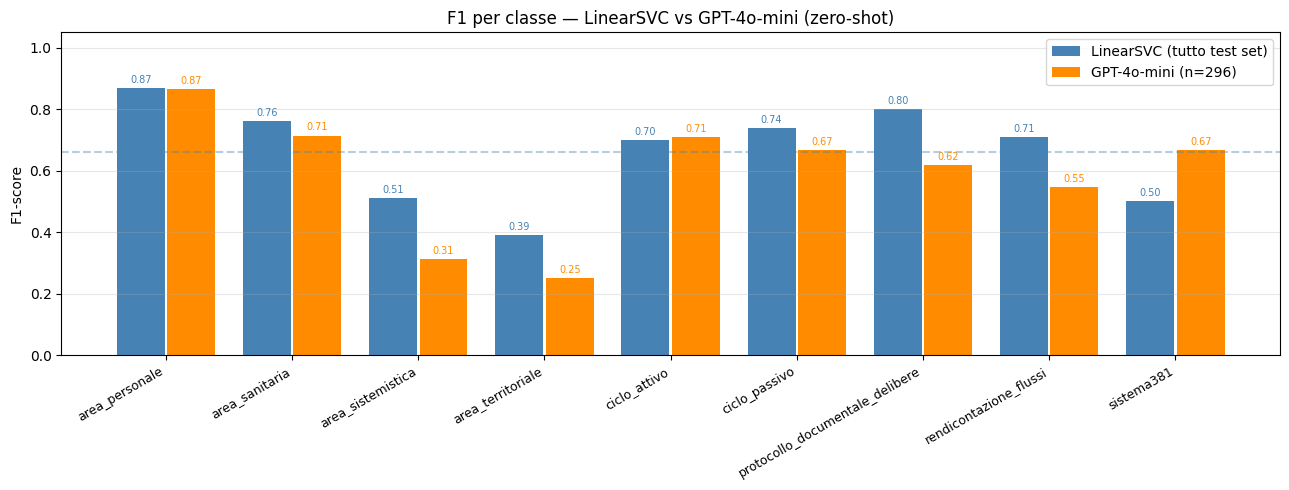

In [30]:
from sklearn.metrics import classification_report as cr

# F1 per classe — GPT
report_gpt = cr(df_ok['area_reale'], df_ok['area_predetta'],
                output_dict=True, zero_division=0)

# F1 per classe — LinearSVC (valori dal run precedente su tutto il test set)
# Aggiorna questi valori se riesegui AreaClassifier
svc_f1 = {
    'area_personale':                  0.87,
    'area_sanitaria':                  0.76,
    'area_sistemistica':               0.51,
    'area_territoriale':               0.39,
    'ciclo_attivo':                    0.70,
    'ciclo_passivo':                   0.74,
    'protocollo_documentale_delibere': 0.80,
    'rendicontazione_flussi':          0.71,
    'sistema381':                      0.50,
}

classi = list(svc_f1.keys())
f1_svc = [svc_f1[c] for c in classi]
f1_gpt = [report_gpt.get(c, {}).get('f1-score', 0) for c in classi]

x = range(len(classi))
fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar([i - 0.2 for i in x], f1_svc, width=0.38, label='LinearSVC (tutto test set)', color='steelblue')
bars2 = ax.bar([i + 0.2 for i in x], f1_gpt, width=0.38, label=f'GPT-4o-mini (n={len(df_ok)})', color='darkorange')

ax.set_xticks(list(x))
ax.set_xticklabels(classi, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.05)
ax.set_title('F1 per classe — LinearSVC vs GPT-4o-mini (zero-shot)')
ax.legend()
ax.axhline(0.66, color='steelblue', linestyle='--', alpha=0.4, label='Macro F1 SVC')
ax.grid(axis='y', alpha=0.3)

# Annota il valore sopra ogni barra
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7, color='steelblue')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7, color='darkorange')

plt.tight_layout()
plt.show()